# Prep the data

We need to subset, clean and standardize the data for the UNet model.

Steps are:
* Load the raw data which has lat, lon, variable with gaps (in our case CHL) with gaps indicated with NaN, a land mask and any predictor variables.
* Subset to our smaller region.
* Add season variables (sin/cos)
* Add prior and next day CHL as extra predictors (in addition to the current day CHL)
* Create a fake clouds that will mask observed CHL
* Add masks for fake clouds (has an observed CHL), real clouds (does not have observed CHL), and valid CHL (observed CHL minus CHL covered with fake cloud).

Scroll to bottom for the code to prep all in one code block.

## Load mindthegap code
It is in the `mindthegap` folder in the root level of the repo.

In [1]:
ROOT_PATH = "/home/jovyan/mindthegap/"
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), ROOT_PATH))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import mindthegap as mtg

### Data Preprocessing
#### 1. Load the dataset
We start by loading the dataset of IO.zarr, slicing the region to the desired dimension, and removing days with no valid CHL data.

In [2]:
import xarray as xr
zarr_ds = xr.open_dataset(
    "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/IO.zarr",
    engine="zarr",
    backend_kwargs={"storage_options": {"token": "anon"}},
    consolidated=True,
    chunks={}
)

In [3]:
# Define bounding box
lat_min, lat_max = 5, 31
lon_min, lon_max = 42, 80

### Show the region

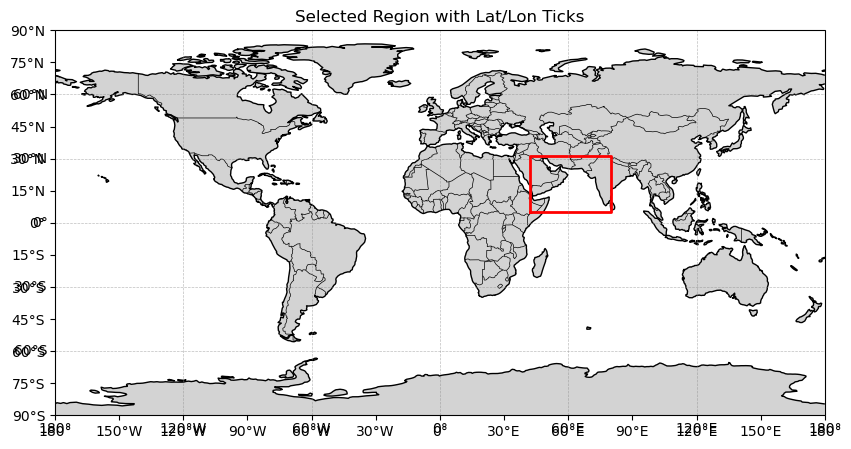

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

# Create a global map
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

# Plot bounding box
ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    transform=ccrs.PlateCarree(),
    color="red", linewidth=2
)

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False   # no labels at top
gl.right_labels = False # no labels at right

# Control tick locations
ax.set_xticks(range(-180, 181, 30), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 15), crs=ccrs.PlateCarree())

# Format tick labels
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

plt.title("Selected Region with Lat/Lon Ticks")
plt.show()


### Slice and subset

In [4]:
import numpy as np
zarr_ds = zarr_ds.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min,lon_max))  # choose long and lat

# remove days with no data
all_nan_CHL = np.isnan(zarr_ds['CHL_cmes-level3']).all(dim=["lon", "lat"]).compute()  # find sample indices where CHL is NaN
zarr_ds = zarr_ds.sel(time=(~all_nan_CHL))  # select samples with CHL not NaN
zarr_ds = zarr_ds.sortby('time')

In [6]:
zarr_ds

<xarray.Dataset> Size: 14GB
Dimensions:                       (time: 9182, lat: 105, lon: 153)
Coordinates:
  * time                          (time) datetime64[ns] 73kB 1997-10-01 ... 2...
  * lat                           (lat) float32 420B 31.0 30.75 ... 5.25 5.0
  * lon                           (lon) float32 612B 42.0 42.25 ... 79.75 80.0
Data variables: (12/27)
    CHL                           (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    CHL_cmes-cloud                (time, lat, lon) uint8 148MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    CHL_cmes-gapfree              (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    CHL_cmes-land                 (lat, lon) uint8 16kB dask.array<chunksize=(105, 153), meta=np.ndarray>
    CHL_cmes-level3               (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    CHL_cmes_flags-gapfree        (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    ...                            ...
    ug_curr                       (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    v_curr                        (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    v_wind                        (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    vg_curr                       (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    wind_dir                      (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    wind_speed                    (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    ...                              ...
    time_coverage_end:               2024-04-18T02:58:23Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2024-04-16T21:12:05Z
    title:                           cmems_obs-oc_glo_bgc-plankton_my_l3-mult...
    westernmost_longitude:           -180.0
    westernmost_valid_longitude:     -180.0

#### 2. Process data

#### Function: `data_preprocessing`
This function selects and standardizes feature variables, and store them to a zarr file for easy access in future training and evaluation.

##### Parameters:
- `zarr_ds`: original zarr dataset after region slicing and NaN CHL filtering
- `features`: a list of features available directly from _zarr_ds_
- `train_year`: the first year of train data
- `train_range`: length of train data in year


##### Other Features (X):
- `sin_time`:
$
\sin({\text{day in the year} \over 366} \cdot 2 \pi)
$
for seasonal information
- `cos_time`:
$
\cos({\text{day in the year} \over 366} \cdot 2 \pi)
$
for seasonal information as well
- `masked_CHL` (logged): artifically masked CHL to simulate cloud coverage. Artificial clouds are the overlapping pixels of _current day observed CHL location_ and _10 day after cloud location_
- `prev_day_CHL`: CHL data from the previous day
- `next_day_CHL`: CHL data from the next day
- `land_flag`: flag for land, with 1 = land and 0 = not land
- `real_cloud_flag`: flag for real cloud, with 1 = real cloud and 0 = not real cloud
- `valid_CHL_flag`: flag for observed CHL after applying artifical masks, with 1 = CHL observed and 0 = CHL not observed
- `fake_cloud_flag`: flag for fake cloud, with 1 = fake cloud and 0 = not fake cloud

##### label (y):
- `CHL` (logged): observed CHL

##### Standardization:
First standardize based on train dataset, and then apply the calculated mean and standard deviation to all data. Only numerical features and the label are standardized. Mean and standard deviation of _CHL_ and _masked_CHL_ are stored in a `.npy` file for evaluation. 

#### Function: `create_zarr`
This function creates a zarr file and stores standardized features and label to the zarr file. 

__Note__: If you run the code for the first time (the `data_preprocessing` function creates the zarr file), it is recommended to restart the kernel and release the memory. Otherwise you might run out of memory during the trainning phase.

In [5]:
ds_std = mtg.data_preprocessing_new(
    zarr_ds,
    target_variable="CHL_cmes-level3",
    missing_flag="CHL_cmes-cloud", # 1 is missing but could be observed; careful that land is not 1
    land_flag="CHL_cmes-land", # 1 is land
    features=['u_wind', 'v_wind', 'sst', 'air_temp'], 
    train_dates=slice("2015-01-01", "2017-12-31"),
    log_target=True,
    missing_flag_shift=10,
    n_temporal_lags=1,  # Number of prev/next days to add
)

target data created from CHL_cmes-level3
target data logged
target masked with synthetic missing added
true missing flag added from CHL_cmes-cloud
land flag added from CHL_cmes-land
flag for the target that we train on (masked target)
synthetic missing flag created from CHL_cmes-cloud with 10 day shift
sin cos day added (not standardized)
masked_target_m1 and masked_target_p1 added


In [6]:
ds_std

<xarray.Dataset> Size: 5GB
Dimensions:                      (time: 9182, lat: 105, lon: 153)
Coordinates:
  * time                         (time) datetime64[ns] 73kB 1997-10-01 ... 20...
  * lat                          (lat) float32 420B 31.0 30.75 30.5 ... 5.25 5.0
  * lon                          (lon) float32 612B 42.0 42.25 ... 79.75 80.0
Data variables: (12/30)
    u_wind                       (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    v_wind                       (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    sst                          (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    air_temp                     (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    full_target                  (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    masked_target                (time, lat, lon) float32 590MB dask.array<chunksize=(99, 105, 153), meta=np.ndarray>
    ...                           ...
    masked_target_train_mean     float64 8B 0.0
    masked_target_train_std      float64 8B 1.0
    masked_target_m1_train_mean  float64 8B 0.0
    masked_target_m1_train_std   float64 8B 1.0
    masked_target_p1_train_mean  float64 8B 0.0
    masked_target_p1_train_std   float64 8B 1.0
Attributes: (12/92)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    ...                              ...
    time_coverage_end:               2024-04-18T02:58:23Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2024-04-16T21:12:05Z
    title:                           cmems_obs-oc_glo_bgc-plankton_my_l3-mult...
    westernmost_longitude:           -180.0
    westernmost_valid_longitude:     -180.0

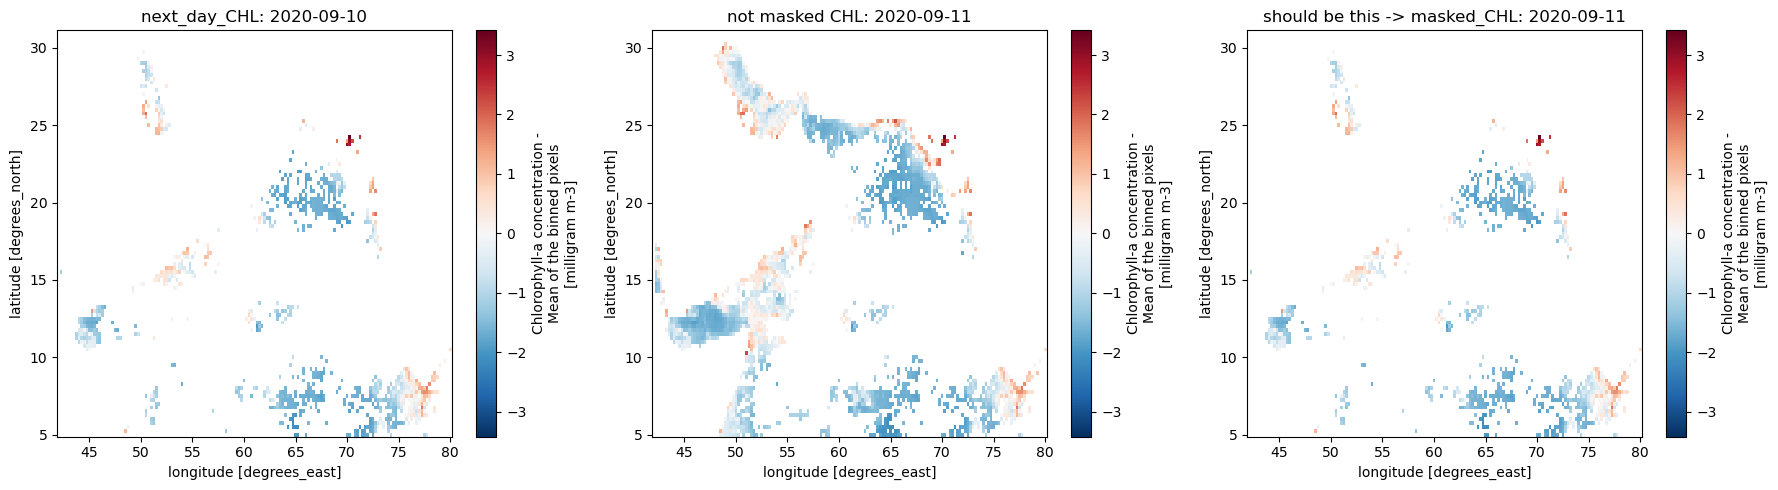

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ds_cropped=ds_std

ds_cropped["masked_target_p1"].sel(time="2020-09-10").plot(
    ax=axes[0],
)
axes[0].set_title("next_day_CHL: 2020-09-10")

ds_cropped["full_target"].sel(time="2020-09-11").plot(
    ax=axes[1],
)
axes[1].set_title("not masked CHL: 2020-09-11")

ds_cropped["masked_target"].sel(time="2020-09-11").plot(
    ax=axes[2],
)
axes[2].set_title("should be this -> masked_CHL: 2020-09-11")

plt.tight_layout()

In [8]:
mtg.create_zarr(
    ds_std,
    filename = "/home/jovyan/shared-public/mindthegap/data/2015_3_ArabSea_20260710.zarr",
)

In [ ]:
#%%script false --no-raise-error
# SAVE TO Google Buckets
import xarray as xr
datadir = "/home/jovyan/shared-public/mindthegap/data"
zarr_label="2015_3_ArabSea_20260710"
zarr_stdized = xr.open_zarr(f'{datadir}/{zarr_label}.zarr')

import gcsfs
fs = gcsfs.GCSFileSystem(token="/home/jovyan/.config/gcloud/application_default_credentials.json")
zarr_path = "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/2015_3_ArabSea_20260710.zarr"
zarr_stdized.to_zarr(
    zarr_path,
    storage_options={"token": "/home/jovyan/.config/gcloud/application_default_credentials.json"},
    mode="w",
    consolidated=True,
    zarr_format=2
)
print("Zarr uploaded to GCS!")

## Loading in saved standardized data

In [9]:
# Later load the data from local drive
import xarray as xr
datadir = "/home/jovyan/shared-public/mindthegap/data"
zarr_label="2015_3_ArabSea_20260710"
zarr_stdized = xr.open_zarr(f'{datadir}/{zarr_label}.zarr')

In [10]:
# Load from Google Buckets
import xarray as xr
zarr_stdized = xr.open_dataset(
    "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/2015_3_ArabSea_20260710.zarr",
    engine="zarr",
    backend_kwargs={"storage_options": {"token": "anon"}},
    consolidated=True,
    chunks={}
)

In [11]:
zarr_stdized

<xarray.Dataset> Size: 21GB
Dimensions:          (time: 16071, lat: 105, lon: 153)
Coordinates:
  * time             (time) datetime64[ns] 129kB 1979-01-01 ... 2022-12-31
  * lat              (lat) float32 420B 31.0 30.75 30.5 30.25 ... 5.5 5.25 5.0
  * lon              (lon) float32 612B 42.0 42.25 42.5 ... 79.5 79.75 80.0
Data variables: (12/14)
    air_temp         (time, lat, lon) float32 1GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    CHL              (time, lat, lon) float32 1GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    cos_time         (time, lat, lon) float32 1GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    fake_cloud_flag  (time, lat, lon) float64 2GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    land_flag        (time, lat, lon) float64 2GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    masked_CHL       (time, lat, lon) float32 1GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    ...               ...
    real_cloud_flag  (time, lat, lon) float64 2GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    sin_time         (time, lat, lon) float32 1GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    sst              (time, lat, lon) float32 1GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    u_wind           (time, lat, lon) float32 1GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    v_wind           (time, lat, lon) float32 1GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>
    valid_CHL_flag   (time, lat, lon) float64 2GB dask.array<chunksize=(100, 105, 153), meta=np.ndarray>